# Experiment 5 — CNN Training and Optimization

**Dataset:** Oxford-IIIT Pet  
**Input:** 224 × 224 × 3  
**Architecture:** MobileNetV2  

The notebook is divided into small, independently runnable cells so expensive experiments can be checked separately.

**Runtime-friendly defaults:** `DATA_FRACTION=0.5`, `EPOCHS=5`, `CV_EPOCHS=2`, `BATCH_SIZE=64`.

For a final run, increase the fraction/epochs if your runtime allows it.


In [1]:
!pip install -U \
    "protobuf>=6.31.1,<7" \
    "tensorflow-datasets" \
    "tensorflow-metadata" \
    "importlib-resources"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 13.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.


In [2]:
import os
import time
import random
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from IPython.display import display
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
SEED = 42
IMG_SIZE = (224, 224)
NUM_CLASSES = 37

EPOCHS = 5
CV_EPOCHS = 2
BATCH_SIZE = 64
DATA_FRACTION = 0.5

AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Configuration ready")


Configuration ready


In [4]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except:
            pass

    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy("mixed_float16")
        print("GPU detected - mixed precision enabled")
    except:
        print("GPU detected - mixed precision not enabled")
else:
    print("WARNING: Running on CPU")


GPU detected - mixed precision enabled


## 1. Load Oxford-IIIT Pet

In [5]:
(ds_train_raw, ds_test_raw), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    shuffle_files=False
)

class_names = ds_info.features["label"].names
NUM_CLASSES = ds_info.features["label"].num_classes

print("Number of classes:", NUM_CLASSES)
print("First classes:", class_names[:5])


Number of classes: 37
First classes: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle']


In [20]:
def tfds_to_numpy(ds):
    images = []
    labels = []

    for image, label in tfds.as_numpy(ds):
        image = tf.image.resize(image, IMG_SIZE).numpy().astype(np.uint8)
        images.append(image)
        labels.append(label)

    return np.stack(images), np.asarray(labels, dtype=np.int32)


In [21]:
train_images, train_labels = tfds_to_numpy(ds_train_raw)
test_images, test_labels = tfds_to_numpy(ds_test_raw)

print("Training images:", train_images.shape)
print("Test images:", test_images.shape)


Training images: (3680, 224, 224, 3)
Test images: (3669, 224, 224, 3)


In [22]:
if DATA_FRACTION < 1.0:
    rng = np.random.default_rng(SEED)

    train_n = int(len(train_images) * DATA_FRACTION)
    test_n = int(len(test_images) * DATA_FRACTION)

    train_idx = rng.choice(len(train_images), train_n, replace=False)
    test_idx = rng.choice(len(test_images), test_n, replace=False)

    train_images = train_images[train_idx]
    train_labels = train_labels[train_idx]

    test_images = test_images[test_idx]
    test_labels = test_labels[test_idx]

print("Training:", train_images.shape)
print("Test:", test_images.shape)


Training: (1840, 224, 224, 3)
Test: (1834, 224, 224, 3)


## 2. Train / Validation Split

In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    train_images,
    train_labels,
    test_size=0.20,
    random_state=SEED,
    stratify=train_labels
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Independent test:", test_images.shape)


Training: (1472, 224, 224, 3)
Validation: (368, 224, 224, 3)
Independent test: (1834, 224, 224, 3)


## 3. tf.data Pipeline

In [13]:
def make_dataset(images, labels, batch_size=BATCH_SIZE, training=False):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))

    if training:
        ds = ds.shuffle(
            buffer_size=min(len(images), 2048),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    def preprocess_data(image, label):
        image = tf.cast(image, tf.float32)
        image = preprocess_input(image)
        return image, label

    ds = ds.map(preprocess_data, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds


In [32]:
train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val, training=False)
test_ds = make_dataset(test_images, test_labels, training=False)

print("Datasets ready")


Datasets ready


## 4. Data Augmentation

In [27]:
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])

print("Augmentation ready")


Augmentation ready


## 5. Weight Initializers

In [29]:
def initializer_by_name(name):
    name = name.lower()

    if name == "zero":
        return keras.initializers.Zeros()
    elif name == "random":
        return keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=SEED)
    elif name in ["xavier", "glorot"]:
        return keras.initializers.GlorotUniform(seed=SEED)
    elif name == "he":
        return keras.initializers.HeNormal(seed=SEED)
    else:
        raise ValueError(f"Unknown initializer: {name}")


## 6. MobileNetV2 Model Builder

In [8]:
def build_mobilenet(
    num_classes=NUM_CLASSES,
    pretrained=False,
    trainable_base=True,
    dropout=0.0,
    l2_value=0.0,
    use_batchnorm=False,
    initializer="he"
):
    weights = "imagenet" if pretrained else None

    base = MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights=weights
    )

    base.trainable = trainable_base

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = augmentation(inputs)
    x = base(
        x,
        training=False if pretrained and not trainable_base else True
    )
    x = layers.GlobalAveragePooling2D()(x)

    if use_batchnorm:
        x = layers.BatchNormalization()(x)

    if l2_value > 0:
        x = layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_value),
            kernel_initializer=initializer_by_name(initializer)
        )(x)
    else:
        x = layers.Dense(
            256,
            activation="relu",
            kernel_initializer=initializer_by_name(initializer)
        )(x)

    if dropout > 0:
        x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32"
    )(x)

    return keras.Model(inputs, outputs)


## 7. Optimizers and Training Helper

In [33]:
def get_optimizer(name="adam", lr=1e-3):
    name = name.lower()

    if name == "sgd":
        return keras.optimizers.SGD(learning_rate=lr)
    elif name == "momentum":
        return keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif name == "rmsprop":
        return keras.optimizers.RMSprop(learning_rate=lr)
    elif name == "adam":
        return keras.optimizers.Adam(learning_rate=lr)
    else:
        raise ValueError(name)


def compile_model(model, optimizer="adam", lr=1e-3):
    model.compile(
        optimizer=get_optimizer(optimizer, lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def train_model(
    model,
    train_data=train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    optimizer="adam",
    lr=1e-3
):
    compile_model(model, optimizer, lr)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=1,
            min_lr=1e-6
        )
    ]

    start = time.time()

    history = model.fit(
        train_data,
        validation_data=validation_data,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    return history, time.time() - start


## 8. Plot Helper

In [15]:
def plot_training_history(history, title="Training History"):
    h = history.history

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(h["loss"], label="Training")
    plt.plot(h["val_loss"], label="Validation")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(np.array(h["accuracy"]) * 100, label="Training")
    plt.plot(np.array(h["val_accuracy"]) * 100, label="Validation")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()


## 9. Baseline

In [16]:
tf.keras.backend.clear_session()
gc.collect()

baseline_model = build_mobilenet(
    pretrained=False,
    trainable_base=True,
    initializer="he"
)

baseline_history, baseline_time = train_model(
    baseline_model,
    optimizer="adam",
    lr=1e-3
)

print("Training time:", baseline_time)


Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 619ms/step - accuracy: 0.0367 - loss: 3.6993 - val_accuracy: 0.0272 - val_loss: 3.6107 - learning_rate: 0.0010
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 541ms/step - accuracy: 0.0428 - loss: 3.5771 - val_accuracy: 0.0326 - val_loss: 3.6104 - learning_rate: 0.0010
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 553ms/step - accuracy: 0.0645 - loss: 3.5172 - val_accuracy: 0.0299 - val_loss: 3.6098 - learning_rate: 0.0010
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 563ms/step - accuracy: 0.0679 - loss: 3.4726 - val_accuracy: 0.0299 - val_loss: 3.6099 - learning_rate: 0.0010
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 591ms/step - accuracy: 0.0917 - loss: 3.3598 - val_accuracy: 0.0272 - val_loss: 3.6106 - learning_rate: 3.0000e-04
Training time: 97.4291582107544


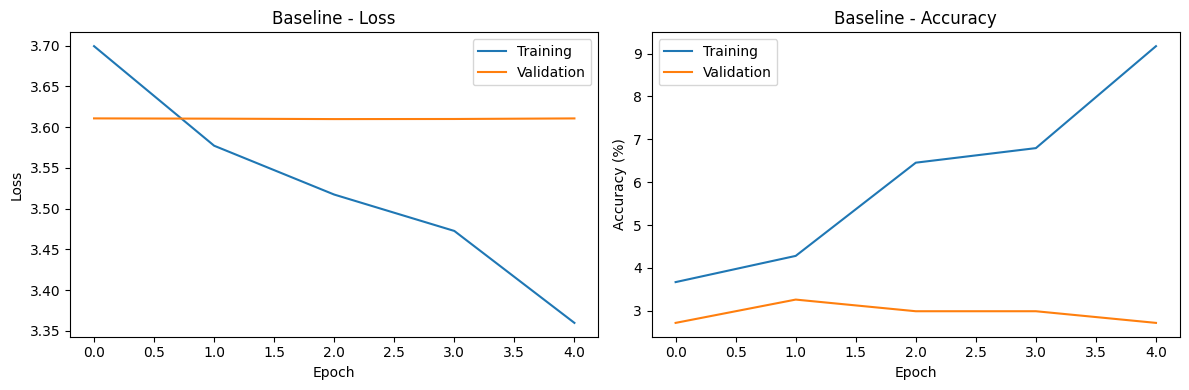

In [17]:
plot_training_history(baseline_history, "Baseline")


## 10. Weight Initialization Experiment

In [18]:
initializers = ["zero", "random", "xavier", "he"]

init_histories = {}
init_times = {}

for init_name in initializers:
    print("\n" + "=" * 50)
    print("Initialization:", init_name)

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_mobilenet(
        pretrained=False,
        trainable_base=True,
        initializer=init_name
    )

    history, elapsed = train_model(
        model,
        optimizer="adam",
        lr=1e-3
    )

    init_histories[init_name] = history
    init_times[init_name] = elapsed

    del model
    gc.collect()



Initialization: zero
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 606ms/step - accuracy: 0.0204 - loss: 3.6110 - val_accuracy: 0.0326 - val_loss: 3.6106 - learning_rate: 0.0010
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 560ms/step - accuracy: 0.0326 - loss: 3.6106 - val_accuracy: 0.0326 - val_loss: 3.6102 - learning_rate: 0.0010
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 583ms/step - accuracy: 0.0258 - loss: 3.6103 - val_accuracy: 0.0326 - val_loss: 3.6100 - learning_rate: 0.0010
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 549ms/step - accuracy: 0.0326 - loss: 3.6100 - val_accuracy: 0.0326 - val_loss: 3.6097 - learning_rate: 0.0010
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 542ms/step - accuracy: 0.0326 - loss: 3.6098 - val_accuracy: 0.0326 - val_loss: 3.6094 - learning_rate: 0.0010

Initialization: random
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 658ms/step - accuracy: 0.0183 - loss: 3.7661 - val_accuracy: 0.0299 - val_loss: 3.6107 - learning_rate: 0.0010
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 5

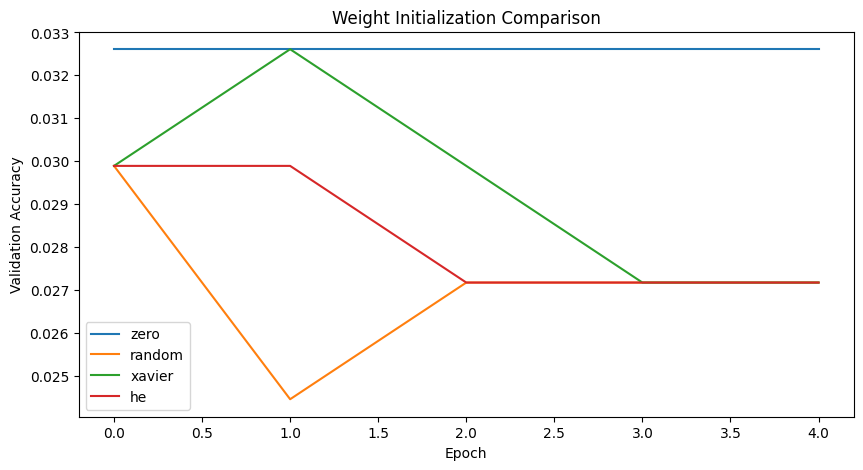

In [19]:
plt.figure(figsize=(10, 5))

for name, history in init_histories.items():
    plt.plot(history.history["val_accuracy"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Weight Initialization Comparison")
plt.legend()
plt.show()


In [20]:
init_results = []

for name, history in init_histories.items():
    init_results.append({
        "Initialization": name,
        "Best Validation Accuracy": max(history.history["val_accuracy"]),
        "Final Training Loss": history.history["loss"][-1],
        "Training Time": init_times[name]
    })

init_df = pd.DataFrame(init_results)
display(init_df)


,Initialization,Best Validation Accuracy,Final Training Loss,Training Time
0,zero,0.032609,3.609782,97.833254
1,random,0.029891,3.344009,92.760433
2,xavier,0.032609,3.286055,97.909230
3,he,0.029891,3.295591,92.038471


## 11. Regularization / Overfitting

In [21]:
regularization_configs = {
    "No Regularization": {
        "dropout": 0.0,
        "l2_value": 0.0,
        "use_batchnorm": False
    },
    "L2": {
        "dropout": 0.0,
        "l2_value": 1e-4,
        "use_batchnorm": False
    },
    "Batch Normalization": {
        "dropout": 0.0,
        "l2_value": 0.0,
        "use_batchnorm": True
    },
    "Dropout": {
        "dropout": 0.5,
        "l2_value": 0.0,
        "use_batchnorm": False
    }
}

reg_histories = {}
reg_times = {}

for name, config in regularization_configs.items():
    print("\nRegularization:", name)

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_mobilenet(
        pretrained=False,
        trainable_base=True,
        initializer="he",
        **config
    )

    history, elapsed = train_model(
        model,
        optimizer="adam",
        lr=1e-3
    )

    reg_histories[name] = history
    reg_times[name] = elapsed

    del model
    gc.collect()



Regularization: No Regularization
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 621ms/step - accuracy: 0.0408 - loss: 3.7242 - val_accuracy: 0.0299 - val_loss: 3.6107 - learning_rate: 0.0010
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 593ms/step - accuracy: 0.0476 - loss: 3.5645 - val_accuracy: 0.0245 - val_loss: 3.6107 - learning_rate: 0.0010
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 617ms/step - accuracy: 0.0645 - loss: 3.4592 - val_accuracy: 0.0272 - val_loss: 3.6106 - learning_rate: 3.0000e-04
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 568ms/step - accuracy: 0.0910 - loss: 3.3950 - val_accuracy: 0.0245 - val_loss: 3.6107 - learning_rate: 3.0000e-04
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 551ms/step - accuracy: 0.1019 - loss: 3.3429 - val_accuracy: 0.0245 - val_loss: 3.6114 - learning_rate: 9.0000e-05

Regularization: L2
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 618ms/step - accuracy: 0.0326 - loss: 3.7385 - val_accuracy: 0.0299 - val_loss: 3.6582 - learning_rate: 0.0010
Epoch 2/5
23/23 ━━━━━

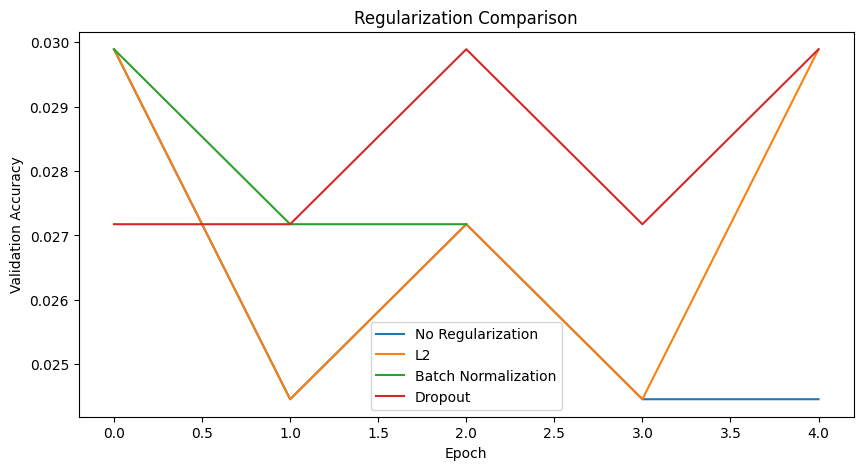

In [22]:
plt.figure(figsize=(10, 5))

for name, history in reg_histories.items():
    plt.plot(history.history["val_accuracy"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Regularization Comparison")
plt.legend()
plt.show()


## 12. Batch Normalization Numerical Example

In [23]:
x = np.array([2., 4., 6., 8.])

mean = np.mean(x)
variance = np.mean((x - mean) ** 2)
normalized = (x - mean) / np.sqrt(variance + 1e-8)

print("Input:", x)
print("Mean:", mean)
print("Variance:", variance)
print("Normalized:", normalized)


Input: [2. 4. 6. 8.]
Mean: 5.0
Variance: 5.0
Normalized: [-1.34164079 -0.4472136   0.4472136   1.34164079]


## 13. Optimizer Experiment

In [24]:
optimizers = ["sgd", "momentum", "rmsprop", "adam"]

optimizer_lrs = {
    "sgd": 1e-2,
    "momentum": 1e-2,
    "rmsprop": 1e-3,
    "adam": 1e-3
}

optimizer_histories = {}
optimizer_times = {}

for opt in optimizers:
    print("\nOptimizer:", opt)

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_mobilenet(
        pretrained=False,
        trainable_base=True,
        initializer="he"
    )

    history, elapsed = train_model(
        model,
        optimizer=opt,
        lr=optimizer_lrs[opt]
    )

    optimizer_histories[opt] = history
    optimizer_times[opt] = elapsed

    del model
    gc.collect()



Optimizer: sgd
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 597ms/step - accuracy: 0.0285 - loss: 3.6619 - val_accuracy: 0.0272 - val_loss: 3.6108 - learning_rate: 0.0100
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 559ms/step - accuracy: 0.0340 - loss: 3.6074 - val_accuracy: 0.0272 - val_loss: 3.6108 - learning_rate: 0.0100
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 605ms/step - accuracy: 0.0374 - loss: 3.5831 - val_accuracy: 0.0272 - val_loss: 3.6108 - learning_rate: 0.0030
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 541ms/step - accuracy: 0.0496 - loss: 3.5749 - val_accuracy: 0.0272 - val_loss: 3.6108 - learning_rate: 9.0000e-04
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 538ms/step - accuracy: 0.0510 - loss: 3.5738 - val_accuracy: 0.0299 - val_loss: 3.6108 - learning_rate: 2.7000e-04

Optimizer: momentum
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 609ms/step - accuracy: 0.0292 - loss: 3.6574 - val_accuracy: 0.0299 - val_loss: 3.6106 - learning_rate: 0.0100
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 58

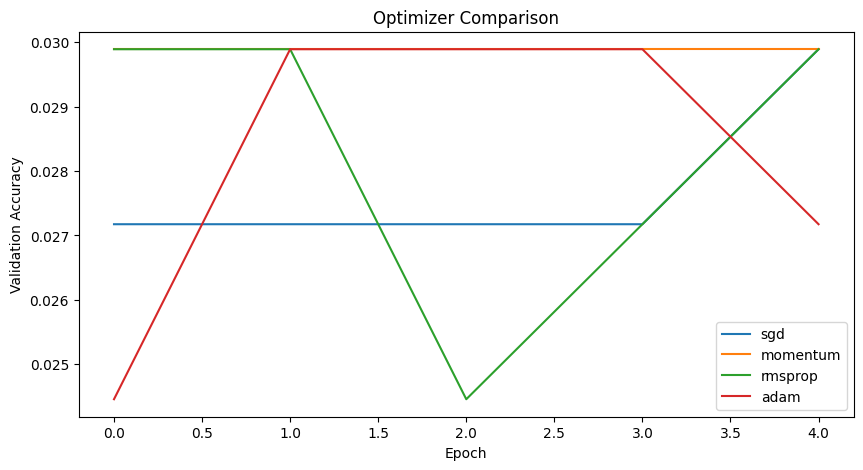

In [25]:
plt.figure(figsize=(10, 5))

for opt, history in optimizer_histories.items():
    plt.plot(history.history["val_accuracy"], label=opt)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison")
plt.legend()
plt.show()


In [26]:
optimizer_results = []

for opt, history in optimizer_histories.items():
    optimizer_results.append({
        "Optimizer": opt,
        "Best Validation Accuracy": max(history.history["val_accuracy"]),
        "Training Time": optimizer_times[opt]
    })

optimizer_df = pd.DataFrame(optimizer_results)
display(optimizer_df)


,Optimizer,Best Validation Accuracy,Training Time
0,sgd,0.029891,82.694843
1,momentum,0.029891,82.348075
2,rmsprop,0.029891,90.394723
3,adam,0.029891,98.038608


## 14. Hyperparameter Tuning

In [27]:
hyper_results = []


In [28]:
for lr in [1e-3, 1e-4]:
    print("Learning rate:", lr)

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_mobilenet(
        pretrained=False,
        trainable_base=True,
        initializer="he"
    )

    history, elapsed = train_model(
        model,
        optimizer="adam",
        lr=lr
    )

    hyper_results.append({
        "Experiment": f"Learning Rate={lr}",
        "Best Validation Accuracy": max(history.history["val_accuracy"]),
        "Best Validation Loss": min(history.history["val_loss"])
    })

    del model
    gc.collect()


Learning rate: 0.001
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 630ms/step - accuracy: 0.0312 - loss: 3.7127 - val_accuracy: 0.0245 - val_loss: 3.6107 - learning_rate: 0.0010
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 611ms/step - accuracy: 0.0510 - loss: 3.5452 - val_accuracy: 0.0299 - val_loss: 3.6104 - learning_rate: 0.0010
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 584ms/step - accuracy: 0.0611 - loss: 3.5080 - val_accuracy: 0.0245 - val_loss: 3.6102 - learning_rate: 0.0010
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 555ms/step - accuracy: 0.0652 - loss: 3.4271 - val_accuracy: 0.0272 - val_loss: 3.6105 - learning_rate: 0.0010
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 549ms/step - accuracy: 0.0904 - loss: 3.3401 - val_accuracy: 0.0299 - val_loss: 3.6111 - learning_rate: 3.0000e-04
Learning rate: 0.0001
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 624ms/step - accuracy: 0.0272 - loss: 3.6367 - val_accuracy: 0.0326 - val_loss: 3.6108 - learning_rate: 1.0000e-04
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 

In [29]:
for bs in [32, 64]:
    print("Batch size:", bs)

    train_bs = make_dataset(X_train, y_train, batch_size=bs, training=True)
    val_bs = make_dataset(X_val, y_val, batch_size=bs, training=False)

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_mobilenet(
        pretrained=False,
        trainable_base=True,
        initializer="he"
    )

    history, elapsed = train_model(
        model,
        train_data=train_bs,
        validation_data=val_bs,
        optimizer="adam",
        lr=1e-3
    )

    hyper_results.append({
        "Experiment": f"Batch Size={bs}",
        "Best Validation Accuracy": max(history.history["val_accuracy"]),
        "Best Validation Loss": min(history.history["val_loss"])
    })

    del model
    gc.collect()


Batch size: 32
Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 40s 333ms/step - accuracy: 0.0333 - loss: 3.6995 - val_accuracy: 0.0272 - val_loss: 3.6103 - learning_rate: 0.0010
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 311ms/step - accuracy: 0.0489 - loss: 3.5769 - val_accuracy: 0.0299 - val_loss: 3.6101 - learning_rate: 0.0010
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 305ms/step - accuracy: 0.0673 - loss: 3.5063 - val_accuracy: 0.0299 - val_loss: 3.6109 - learning_rate: 0.0010
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 13s 292ms/step - accuracy: 0.0740 - loss: 3.4210 - val_accuracy: 0.0299 - val_loss: 3.6140 - learning_rate: 3.0000e-04
Batch size: 64
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 614ms/step - accuracy: 0.0326 - loss: 3.6960 - val_accuracy: 0.0272 - val_loss: 3.6109 - learning_rate: 0.0010
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 574ms/step - accuracy: 0.0564 - loss: 3.5569 - val_accuracy: 0.0299 - val_loss: 3.6105 - learning_rate: 0.0010
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 590ms/step - 

In [30]:
for dropout in [0.0, 0.25, 0.5]:
    print("Dropout:", dropout)

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_mobilenet(
        pretrained=False,
        trainable_base=True,
        dropout=dropout,
        initializer="he"
    )

    history, elapsed = train_model(
        model,
        optimizer="adam",
        lr=1e-3
    )

    hyper_results.append({
        "Experiment": f"Dropout={dropout}",
        "Best Validation Accuracy": max(history.history["val_accuracy"]),
        "Best Validation Loss": min(history.history["val_loss"])
    })

    del model
    gc.collect()


Dropout: 0.0
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 621ms/step - accuracy: 0.0319 - loss: 3.6918 - val_accuracy: 0.0272 - val_loss: 3.6109 - learning_rate: 0.0010
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 599ms/step - accuracy: 0.0510 - loss: 3.5729 - val_accuracy: 0.0272 - val_loss: 3.6104 - learning_rate: 0.0010
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 604ms/step - accuracy: 0.0625 - loss: 3.5189 - val_accuracy: 0.0272 - val_loss: 3.6103 - learning_rate: 0.0010
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 559ms/step - accuracy: 0.0720 - loss: 3.4631 - val_accuracy: 0.0272 - val_loss: 3.6106 - learning_rate: 0.0010
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 549ms/step - accuracy: 0.0958 - loss: 3.3489 - val_accuracy: 0.0272 - val_loss: 3.6108 - learning_rate: 3.0000e-04
Dropout: 0.25
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 622ms/step - accuracy: 0.0353 - loss: 3.7299 - val_accuracy: 0.0272 - val_loss: 3.6106 - learning_rate: 0.0010
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 600ms/step - acc

In [31]:
hyper_df = pd.DataFrame(hyper_results)
display(hyper_df)


,Experiment,Best Validation Accuracy,Best Validation Loss
0,Learning Rate=0.001,0.029891,3.610183
1,Learning Rate=0.0001,0.032609,3.610063
2,Batch Size=32,0.029891,3.610056
3,Batch Size=64,0.029891,3.610139
4,Dropout=0.0,0.027174,3.610265
5,Dropout=0.25,0.029891,3.609299
6,Dropout=0.5,0.032609,3.609185


## 15. Transfer Learning — Feature Extraction

In [32]:
tf.keras.backend.clear_session()
gc.collect()

feature_model = build_mobilenet(
    pretrained=True,
    trainable_base=False,
    dropout=0.25
)

feature_history, feature_time = train_model(
    feature_model,
    optimizer="adam",
    lr=1e-3
)

print("Feature extraction time:", feature_time)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 237ms/step - accuracy: 0.1515 - loss: 3.3684 - val_accuracy: 0.4674 - val_loss: 2.4225 - learning_rate: 0.0010
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - accuracy: 0.3995 - loss: 2.2225 - val_accuracy: 0.6495 - val_loss: 1.4870 - learning_rate: 0.0010
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.5027 - loss: 1.7087 - val_accuracy: 0.7065 - val_loss: 1.1708 - learning_rate: 0.0010
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.5768 - loss: 1.4236 - val_accuracy: 0.7255 - val_loss: 0.9933 - learning_rate: 0.0010
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.6420 - loss: 1.1988 - val_accuracy: 0.7853 - val_loss: 0.8866 - learning_rate: 0.0010
Feature extraction time: 28.55538058280945


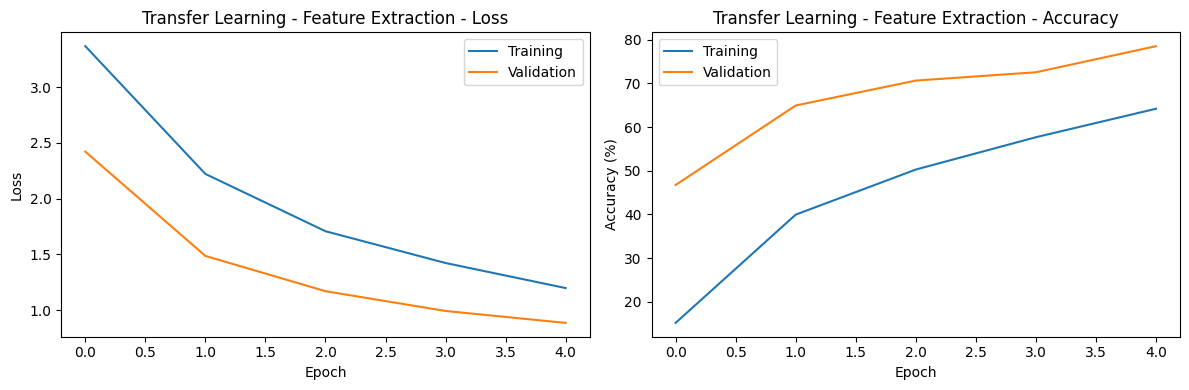

In [33]:
plot_training_history(
    feature_history,
    "Transfer Learning - Feature Extraction"
)


## 16. Transfer Learning — Fine-Tuning

In [34]:
tf.keras.backend.clear_session()
gc.collect()

fine_model = build_mobilenet(
    pretrained=True,
    trainable_base=False,
    dropout=0.25
)

stage1_history, stage1_time = train_model(
    fine_model,
    optimizer="adam",
    lr=1e-3,
    epochs=3
)


Epoch 1/3
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 248ms/step - accuracy: 0.1603 - loss: 3.2584 - val_accuracy: 0.5462 - val_loss: 2.1437 - learning_rate: 0.0010
Epoch 2/3
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.4137 - loss: 2.1084 - val_accuracy: 0.6630 - val_loss: 1.3573 - learning_rate: 0.0010
Epoch 3/3
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.5217 - loss: 1.6585 - val_accuracy: 0.7065 - val_loss: 1.0917 - learning_rate: 0.0010


In [35]:
base = None

for layer in fine_model.layers:
    if isinstance(layer, keras.Model) and "mobilenet" in layer.name.lower():
        base = layer
        break

print("Base found:", base is not None)

if base is not None:
    base.trainable = True

    for layer in base.layers[:-30]:
        layer.trainable = False

    for layer in base.layers[-30:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

print(
    "Trainable layers:",
    sum(layer.trainable for layer in fine_model.layers)
)


Base found: True
Trainable layers: 7


In [36]:
compile_model(
    fine_model,
    optimizer="adam",
    lr=1e-5
)

start = time.time()

stage2_history = fine_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=1,
            restore_best_weights=True
        )
    ],
    verbose=1
)

fine_tune_time = time.time() - start
print("Fine-tuning time:", fine_tune_time)


Epoch 1/3
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 228ms/step - accuracy: 0.6121 - loss: 1.3183 - val_accuracy: 0.7418 - val_loss: 1.0193
Epoch 2/3
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.6250 - loss: 1.2330 - val_accuracy: 0.7446 - val_loss: 0.9759
Epoch 3/3
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.6304 - loss: 1.1916 - val_accuracy: 0.7446 - val_loss: 0.9502
Fine-tuning time: 20.188673734664917


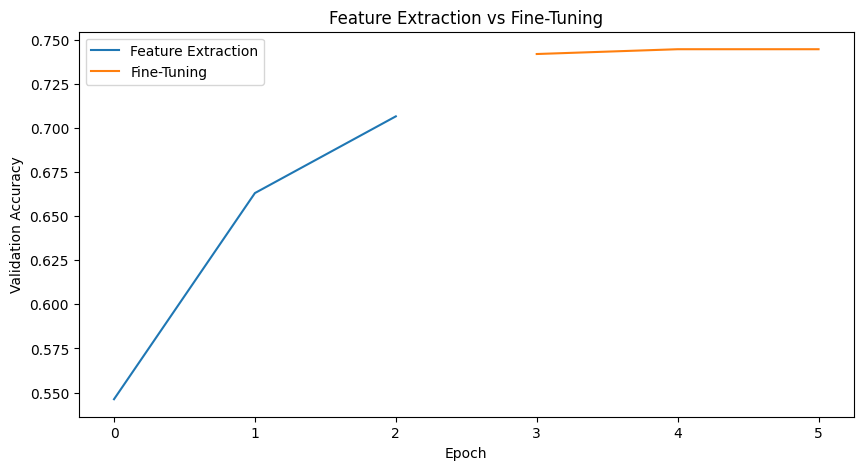

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    stage1_history.history["val_accuracy"],
    label="Feature Extraction"
)

plt.plot(
    range(
        len(stage1_history.history["val_accuracy"]),
        len(stage1_history.history["val_accuracy"]) +
        len(stage2_history.history["val_accuracy"])
    ),
    stage2_history.history["val_accuracy"],
    label="Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Feature Extraction vs Fine-Tuning")
plt.legend()
plt.show()


## 17. 5-Fold Cross-Validation

In [24]:
cv_configs = [
    {
        "name": "C1_He_Adam",
        "initializer": "he",
        "dropout": 0.0,
        "l2_value": 0.0,
        "use_batchnorm": False,
        "lr": 1e-3,
        "optimizer": "adam"
    },
    {
        "name": "C2_He_Dropout",
        "initializer": "he",
        "dropout": 0.5,
        "l2_value": 0.0,
        "use_batchnorm": False,
        "lr": 1e-3,
        "optimizer": "adam"
    },
    {
        "name": "C3_He_BN",
        "initializer": "he",
        "dropout": 0.0,
        "l2_value": 0.0,
        "use_batchnorm": True,
        "lr": 1e-3,
        "optimizer": "adam"
    }
]

CV_EPOCHS = 2
X_cv = train_images
y_cv = train_labels

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cv_rows = []

print(
    "CV ready:",
    len(cv_configs),
    "configurations × 5 folds ×",
    CV_EPOCHS,
    "epochs"
)


CV ready: 3 configurations × 5 folds × 2 epochs


### CV Configuration 1 — C1_He_Adam

In [39]:
config = cv_configs[0]

print("Running:", config["name"])

fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_cv, y_cv),
    start=1
):
    print(f"\n========== FOLD {fold}/5 ==========")

    tf.keras.backend.clear_session()
    gc.collect()

    fold_train_ds = make_dataset(
        X_cv[train_idx],
        y_cv[train_idx],
        batch_size=BATCH_SIZE,
        training=True
    )

    fold_val_ds = make_dataset(
        X_cv[val_idx],
        y_cv[val_idx],
        batch_size=BATCH_SIZE,
        training=False
    )

    model = build_mobilenet(
        pretrained=False,
        trainable_base=True,
        initializer=config["initializer"],
        dropout=config["dropout"],
        l2_value=config["l2_value"],
        use_batchnorm=config["use_batchnorm"]
    )

    history, elapsed = train_model(
        model,
        train_data=fold_train_ds,
        validation_data=fold_val_ds,
        epochs=CV_EPOCHS,
        optimizer=config["optimizer"],
        lr=config["lr"]
    )

    best_acc = max(history.history["val_accuracy"])
    fold_accuracies.append(best_acc)

    print("Fold accuracy:", best_acc)

    del model, history
    gc.collect()

print("C1_He_Adam results:", fold_accuracies)


Running: C1_He_Adam

========== FOLD 1/5 ==========
Epoch 1/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 653ms/step - accuracy: 0.0340 - loss: 3.7195 - val_accuracy: 0.0272 - val_loss: 3.6107 - learning_rate: 0.0010
Epoch 2/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 609ms/step - accuracy: 0.0516 - loss: 3.5696 - val_accuracy: 0.0272 - val_loss: 3.6107 - learning_rate: 0.0010
Fold accuracy: 0.027173912152647972

========== FOLD 2/5 ==========
Epoch 1/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 633ms/step - accuracy: 0.0346 - loss: 3.6862 - val_accuracy: 0.0272 - val_loss: 3.6107 - learning_rate: 0.0010
Epoch 2/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 616ms/step - accuracy: 0.0462 - loss: 3.5498 - val_accuracy: 0.0245 - val_loss: 3.6105 - learning_rate: 0.0010
Fold accuracy: 0.027173912152647972

========== FOLD 3/5 ==========
Epoch 1/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 633ms/step - accuracy: 0.0346 - loss: 3.7438 - val_accuracy: 0.0299 - val_loss: 3.6107 - learning_rate: 0.0010
Epoch 2/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 617ms/step 

In [40]:
cv_rows.append({
    "Configuration": config["name"],
    "F1": fold_accuracies[0],
    "F2": fold_accuracies[1],
    "F3": fold_accuracies[2],
    "F4": fold_accuracies[3],
    "F5": fold_accuracies[4],
    "Mean": np.mean(fold_accuracies),
    "SD": np.std(fold_accuracies)
})

cv_df = pd.DataFrame(cv_rows)
display(cv_df)

cv_df.to_csv(
    "cv_results.csv",
    index=False
)


,Configuration,F1,F2,F3,F4,F5,Mean,SD
0,C1_He_Adam,0.027174,0.027174,0.029891,0.029891,0.029891,0.028804,0.001331


### CV Configuration 2 — C2_He_Dropout

In [41]:
config = cv_configs[1]

print("Running:", config["name"])

fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_cv, y_cv),
    start=1
):
    print(f"\n========== FOLD {fold}/5 ==========")

    tf.keras.backend.clear_session()
    gc.collect()

    fold_train_ds = make_dataset(
        X_cv[train_idx],
        y_cv[train_idx],
        batch_size=BATCH_SIZE,
        training=True
    )

    fold_val_ds = make_dataset(
        X_cv[val_idx],
        y_cv[val_idx],
        batch_size=BATCH_SIZE,
        training=False
    )

    model = build_mobilenet(
        pretrained=False,
        trainable_base=True,
        initializer=config["initializer"],
        dropout=config["dropout"],
        l2_value=config["l2_value"],
        use_batchnorm=config["use_batchnorm"]
    )

    history, elapsed = train_model(
        model,
        train_data=fold_train_ds,
        validation_data=fold_val_ds,
        epochs=CV_EPOCHS,
        optimizer=config["optimizer"],
        lr=config["lr"]
    )

    best_acc = max(history.history["val_accuracy"])
    fold_accuracies.append(best_acc)

    print("Fold accuracy:", best_acc)

    del model, history
    gc.collect()

print("C2_He_Dropout results:", fold_accuracies)


Running: C2_He_Dropout

========== FOLD 1/5 ==========
Epoch 1/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 642ms/step - accuracy: 0.0279 - loss: 3.7480 - val_accuracy: 0.0299 - val_loss: 3.6107 - learning_rate: 0.0010
Epoch 2/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 612ms/step - accuracy: 0.0333 - loss: 3.6152 - val_accuracy: 0.0299 - val_loss: 3.6103 - learning_rate: 0.0010
Fold accuracy: 0.029891304671764374

========== FOLD 2/5 ==========
Epoch 1/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 628ms/step - accuracy: 0.0265 - loss: 3.7470 - val_accuracy: 0.0272 - val_loss: 3.6107 - learning_rate: 0.0010
Epoch 2/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 601ms/step - accuracy: 0.0374 - loss: 3.6189 - val_accuracy: 0.0272 - val_loss: 3.6105 - learning_rate: 0.0010
Fold accuracy: 0.027173912152647972

========== FOLD 3/5 ==========
Epoch 1/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 640ms/step - accuracy: 0.0306 - loss: 3.7532 - val_accuracy: 0.0326 - val_loss: 3.6108 - learning_rate: 0.0010
Epoch 2/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 616ms/st

In [42]:
cv_rows.append({
    "Configuration": config["name"],
    "F1": fold_accuracies[0],
    "F2": fold_accuracies[1],
    "F3": fold_accuracies[2],
    "F4": fold_accuracies[3],
    "F5": fold_accuracies[4],
    "Mean": np.mean(fold_accuracies),
    "SD": np.std(fold_accuracies)
})

cv_df = pd.DataFrame(cv_rows)
display(cv_df)

cv_df.to_csv(
    "cv_results.csv",
    index=False
)


,Configuration,F1,F2,F3,F4,F5,Mean,SD
0,C1_He_Adam,0.027174,0.027174,0.029891,0.029891,0.029891,0.028804,0.001331
1,C2_He_Dropout,0.029891,0.027174,0.032609,0.029891,0.029891,0.029891,0.001719


### CV Configuration 3 — C3_He_BN

In [35]:
config = cv_configs[2]

print("Running:", config["name"])

fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_cv, y_cv),
    start=1
):
    print(f"\n========== FOLD {fold}/5 ==========")

    tf.keras.backend.clear_session()
    gc.collect()

    fold_train_ds = make_dataset(
        X_cv[train_idx],
        y_cv[train_idx],
        batch_size=BATCH_SIZE,
        training=True
    )

    fold_val_ds = make_dataset(
        X_cv[val_idx],
        y_cv[val_idx],
        batch_size=BATCH_SIZE,
        training=False
    )

    model = build_mobilenet(
        pretrained=False,
        trainable_base=True,
        initializer=config["initializer"],
        dropout=config["dropout"],
        l2_value=config["l2_value"],
        use_batchnorm=config["use_batchnorm"]
    )

    history, elapsed = train_model(
        model,
        train_data=fold_train_ds,
        validation_data=fold_val_ds,
        epochs=CV_EPOCHS,
        optimizer=config["optimizer"],
        lr=config["lr"]
    )

    best_acc = max(history.history["val_accuracy"])
    fold_accuracies.append(best_acc)

    print("Fold accuracy:", best_acc)

    del model, history
    gc.collect()

print("C3_He_BN results:", fold_accuracies)


Running: C3_He_BN

========== FOLD 1/5 ==========
Epoch 1/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 48s 738ms/step - accuracy: 0.0421 - loss: 4.3070 - val_accuracy: 0.0272 - val_loss: 3.6130 - learning_rate: 0.0010
Epoch 2/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 574ms/step - accuracy: 0.0367 - loss: 3.9075 - val_accuracy: 0.0299 - val_loss: 3.6259 - learning_rate: 0.0010
Fold accuracy: 0.029891304671764374

========== FOLD 2/5 ==========
Epoch 1/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 615ms/step - accuracy: 0.0428 - loss: 4.2460 - val_accuracy: 0.0245 - val_loss: 3.6159 - learning_rate: 0.0010
Epoch 2/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 573ms/step - accuracy: 0.0489 - loss: 3.9738 - val_accuracy: 0.0272 - val_loss: 3.6277 - learning_rate: 0.0010
Fold accuracy: 0.027173912152647972

========== FOLD 3/5 ==========
Epoch 1/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 40s 666ms/step - accuracy: 0.0380 - loss: 4.3313 - val_accuracy: 0.0272 - val_loss: 3.6168 - learning_rate: 0.0010
Epoch 2/2
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 609ms/step - 

In [36]:
cv_rows.append({
    "Configuration": config["name"],
    "F1": fold_accuracies[0],
    "F2": fold_accuracies[1],
    "F3": fold_accuracies[2],
    "F4": fold_accuracies[3],
    "F5": fold_accuracies[4],
    "Mean": np.mean(fold_accuracies),
    "SD": np.std(fold_accuracies)
})

cv_df = pd.DataFrame(cv_rows)
display(cv_df)

cv_df.to_csv(
    "cv_results.csv",
    index=False
)


,Configuration,F1,F2,F3,F4,F5,Mean,SD
0,C3_He_BN,0.029891,0.027174,0.027174,0.029891,0.029891,0.028804,0.001331


## 18. Select Best Configuration

In [37]:
cv_df = pd.DataFrame(cv_rows)

display(
    cv_df.sort_values(
        "Mean",
        ascending=False
    )
)

best_config_name = cv_df.loc[
    cv_df["Mean"].idxmax(),
    "Configuration"
]

best_config = next(
    config
    for config in cv_configs
    if config["name"] == best_config_name
)

print("Best configuration:")
print(best_config)


,Configuration,F1,F2,F3,F4,F5,Mean,SD
0,C3_He_BN,0.029891,0.027174,0.027174,0.029891,0.029891,0.028804,0.001331


Best configuration:
{'name': 'C3_He_BN', 'initializer': 'he', 'dropout': 0.0, 'l2_value': 0.0, 'use_batchnorm': True, 'lr': 0.001, 'optimizer': 'adam'}


## 19. Final Training on All Training Data

In [38]:
full_train_ds = make_dataset(
    train_images,
    train_labels,
    batch_size=BATCH_SIZE,
    training=True
)

print("Final training dataset ready")


Final training dataset ready


In [39]:
tf.keras.backend.clear_session()
gc.collect()

final_model = build_mobilenet(
    pretrained=False,
    trainable_base=True,
    initializer=best_config["initializer"],
    dropout=best_config["dropout"],
    l2_value=best_config["l2_value"],
    use_batchnorm=best_config["use_batchnorm"]
)

compile_model(
    final_model,
    optimizer=best_config["optimizer"],
    lr=best_config["lr"]
)

print(
    "Final model parameters:",
    final_model.count_params()
)


Final model parameters: 2600549


In [40]:
FINAL_EPOCHS = CV_EPOCHS

start = time.time()

final_history = final_model.fit(
    full_train_ds,
    epochs=FINAL_EPOCHS,
    verbose=1
)

final_training_time = time.time() - start

print("Training time:", final_training_time)


Epoch 1/2
29/29 ━━━━━━━━━━━━━━━━━━━━ 42s 579ms/step - accuracy: 0.0408 - loss: 4.2926
Epoch 2/2
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 573ms/step - accuracy: 0.0489 - loss: 3.9362
Training time: 58.543832540512085


## 20. Independent Test Evaluation

In [41]:
test_loss, test_accuracy = final_model.evaluate(
    test_ds,
    verbose=1
)

print("Final Test Loss:", test_loss)
print("Final Test Accuracy:", test_accuracy)


29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - accuracy: 0.0305 - loss: 3.6239
Final Test Loss: 3.6238996982574463
Final Test Accuracy: 0.030534351244568825


In [42]:
y_true = []
y_pred = []

for images, labels in test_ds:
    probabilities = final_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

y_true = np.asarray(y_true)
y_pred = np.asarray(y_pred)

print("Predictions generated:", len(y_pred))


Predictions generated: 1834


In [43]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Accuracy :", test_accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


Accuracy : 0.030534351244568825
Precision: 0.0009323465998484937
Recall   : 0.030534351145038167
F1 Score : 0.0018094430308170767


In [44]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)


                            precision    recall  f1-score   support

                Abyssinian       0.00      0.00      0.00        48
          american_bulldog       0.00      0.00      0.00        45
 american_pit_bull_terrier       0.00      0.00      0.00        50
              basset_hound       0.00      0.00      0.00        59
                    beagle       0.00      0.00      0.00        54
                    Bengal       0.00      0.00      0.00        43
                    Birman       0.00      0.00      0.00        58
                    Bombay       0.00      0.00      0.00        44
                     boxer       0.00      0.00      0.00        56
         British_Shorthair       0.00      0.00      0.00        57
                 chihuahua       0.00      0.00      0.00        48
              Egyptian_Mau       0.00      0.00      0.00        54
    english_cocker_spaniel       0.00      0.00      0.00        54
            english_setter       0.00      0.00

## 21. Confusion Matrix

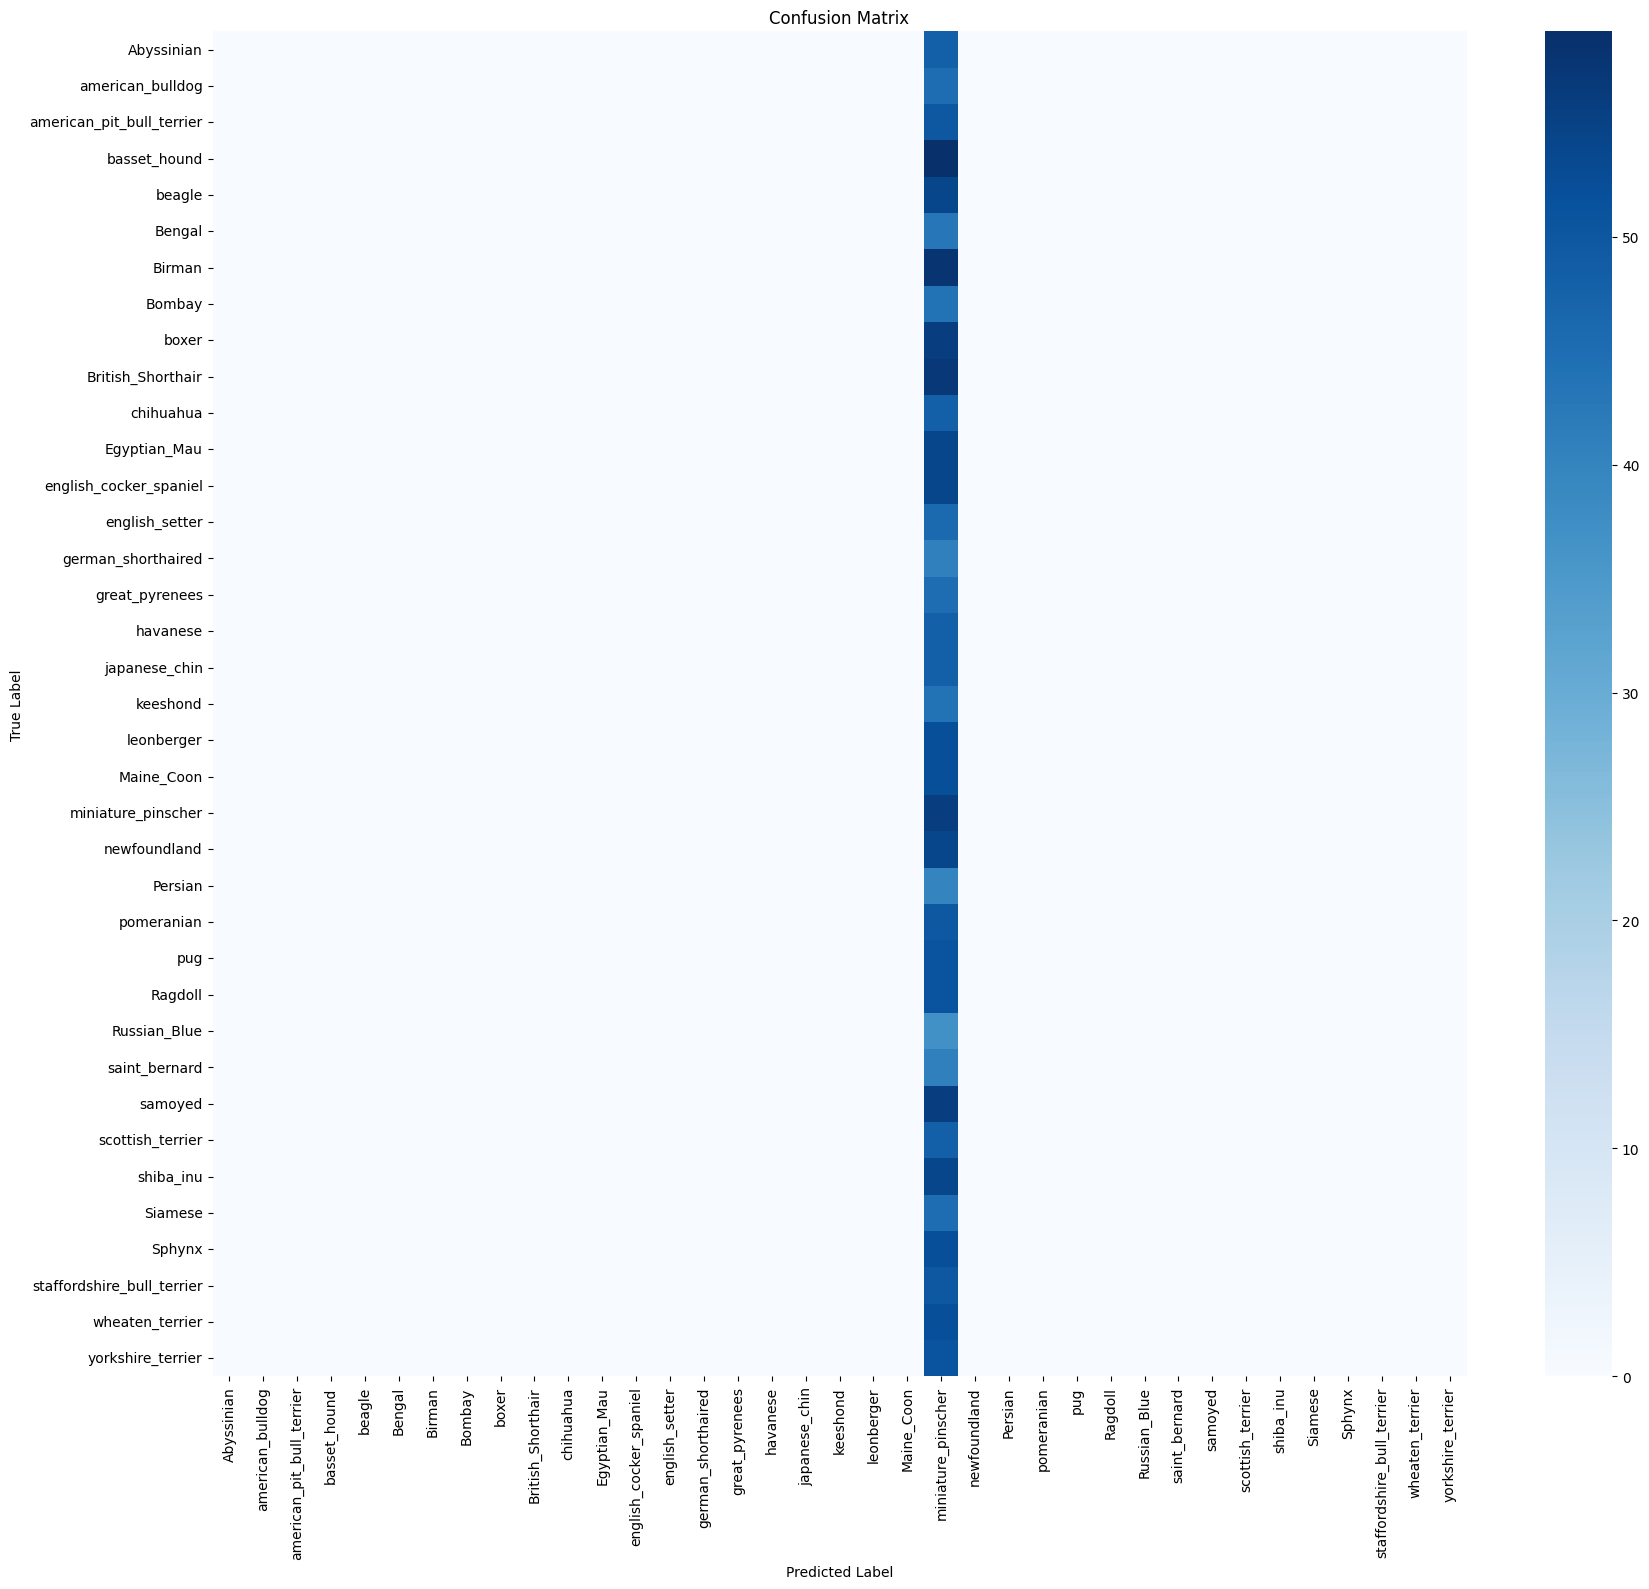

In [45]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


## 22. Misclassified Images

Misclassified: 1778


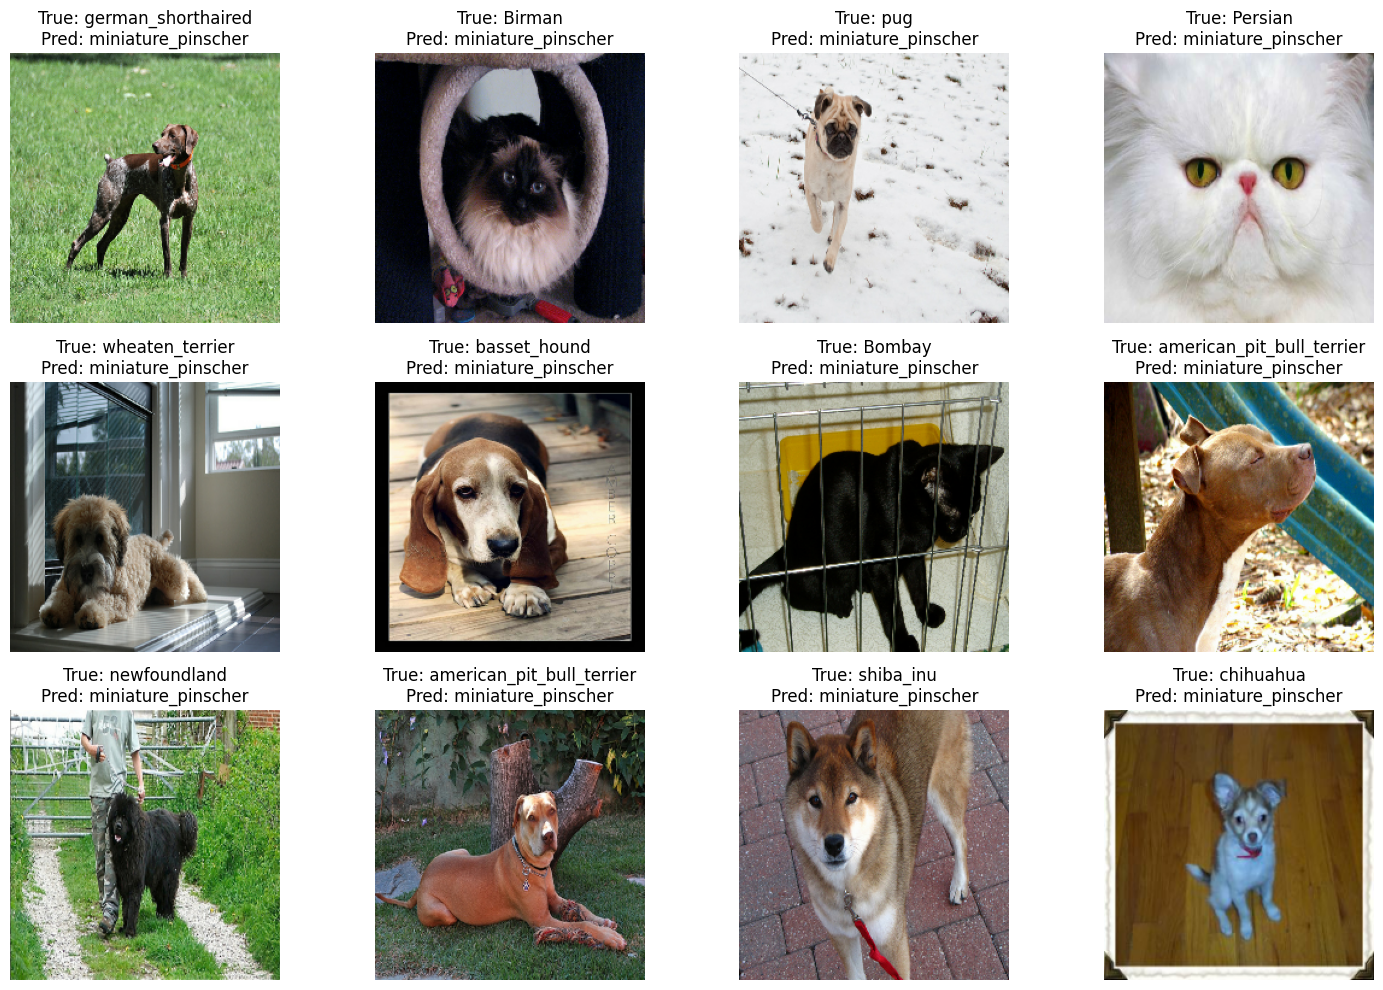

In [46]:
wrong_idx = np.where(y_true != y_pred)[0]

print("Misclassified:", len(wrong_idx))

n_show = min(12, len(wrong_idx))

plt.figure(figsize=(15, 10))

for i in range(n_show):
    idx = wrong_idx[i]

    plt.subplot(3, 4, i + 1)
    plt.imshow(test_images[idx])

    plt.title(
        f"True: {class_names[y_true[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


## 23. Final Results

In [47]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Mean CV Accuracy",
        "CV Standard Deviation",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (sec)",
        "Number of Parameters"
    ],
    "Value": [
        cv_df.loc[
            cv_df["Configuration"] == best_config_name,
            "Mean"
        ].iloc[0],

        cv_df.loc[
            cv_df["Configuration"] == best_config_name,
            "SD"
        ].iloc[0],

        test_accuracy,
        precision,
        recall,
        f1,
        final_training_time,
        final_model.count_params()
    ]
})

display(final_metrics)


,Metric,Value
0,Mean CV Accuracy,2.880435e-02
1,CV Standard Deviation,1.331245e-03
2,Test Accuracy,3.053435e-02
3,Precision,9.323466e-04
4,Recall,3.053435e-02
5,F1 Score,1.809443e-03
6,Training Time (sec),5.854383e+01
7,Number of Parameters,2.600549e+06
